------------------------------
Accuracy (R-Squared) = 82.85 %
Average Error (MAE)  = $10.78
------------------------------


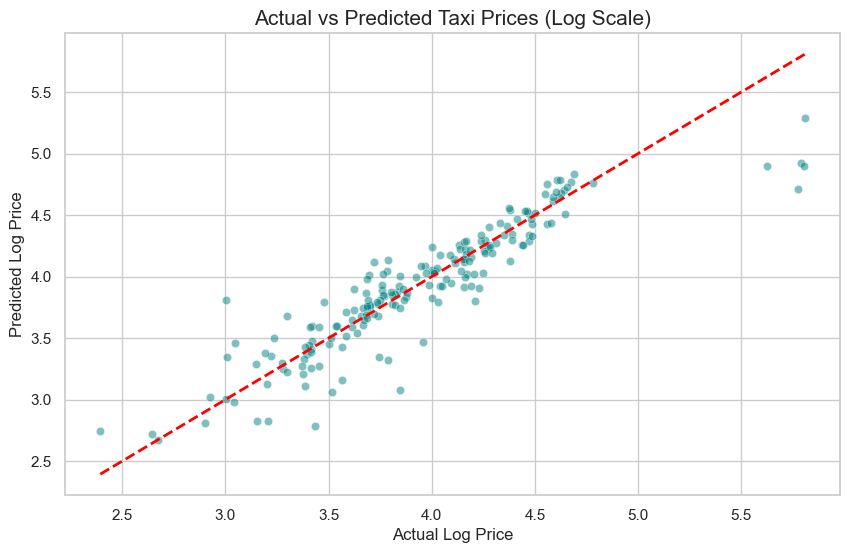

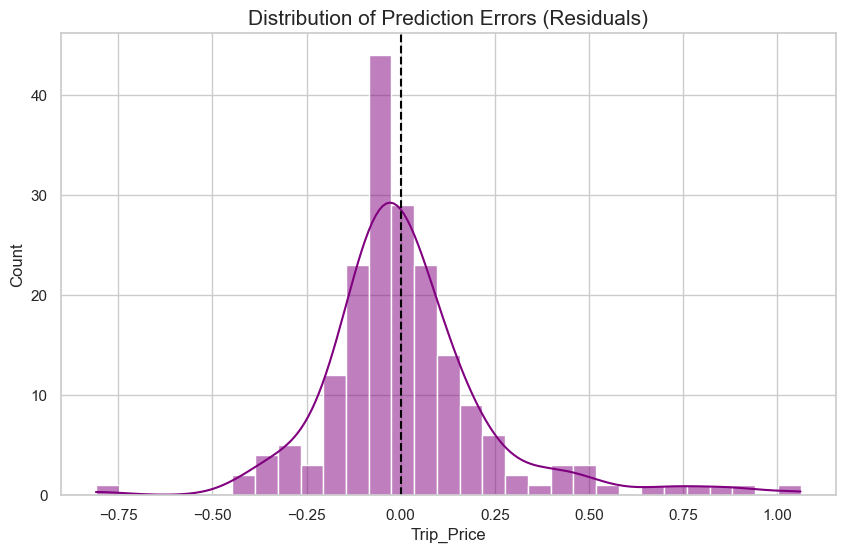

C:\Users\medoc\AppData\Local\Temp\ipykernel_18012\2474784904.py:88: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance, x='Weight', y='Feature', palette='viridis')


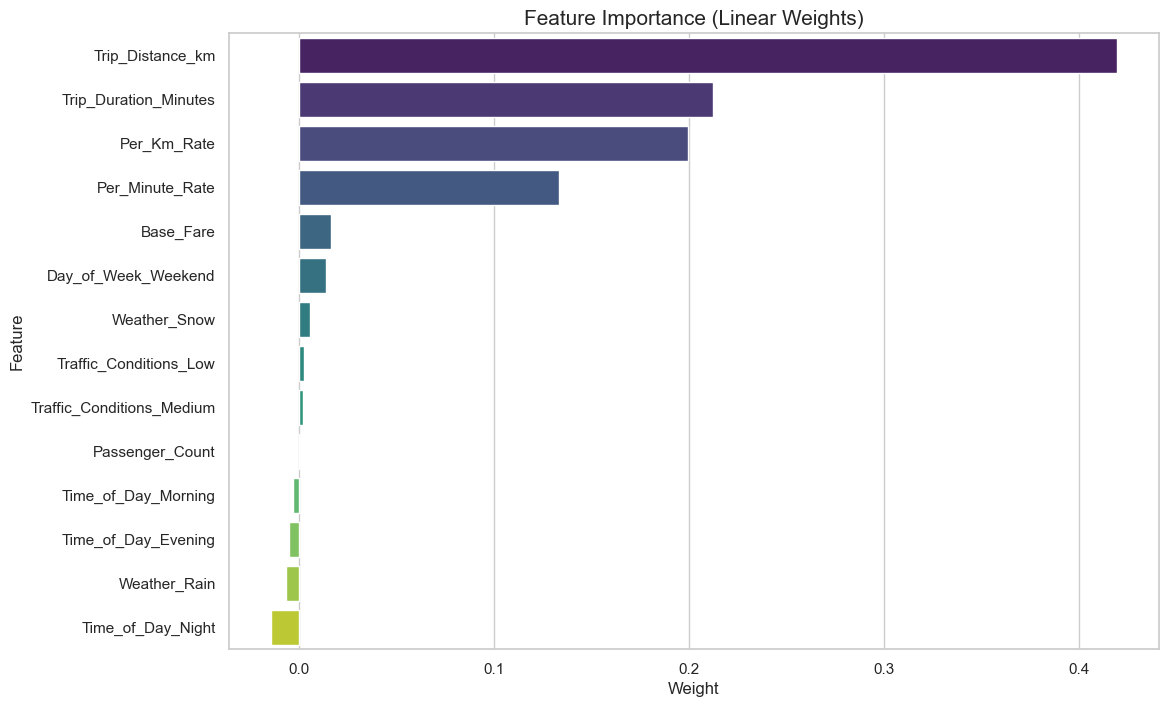

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error

# 1. Initialization
sns.set(style="whitegrid")

# 2. Data Loading & Cleaning
df = pd.read_csv('data/taxi_trip_pricing.csv')

# Drop rows where target is missing
df = df.dropna(subset=['Trip_Price'])

# Fill missing numerical values with median
num_cols = df.select_dtypes(include=[np.number]).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

# Fill missing categorical values with mode
cat_cols = ['Time_of_Day', 'Day_of_Week', 'Traffic_Conditions', 'Weather']
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

# 3. Handling Outliers (Log Transformation)
# This improves Linear Regression performance significantly
df['Trip_Price'] = np.log1p(df['Trip_Price'])
df['Trip_Distance_km'] = np.log1p(df['Trip_Distance_km'])

# 4. Encoding & Splitting
# Convert categories to binary (One-Hot)
df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=True)

X = df_encoded.drop(columns=['Trip_Price'])
y = df_encoded['Trip_Price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 5. Standardization (Preserving Feature Names to stop the Warning)
scaler = StandardScaler()
# We wrap the output back into a DataFrame to keep names
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)

# 6. Model Training
model = LinearRegression()
model.fit(X_train_scaled, y_train)

# 7. Model Prediction & Evaluation
y_pred = model.predict(X_test_scaled)

# Metrics (Styled like your classification task)
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(np.expm1(y_test), np.expm1(y_pred)) # MAE in actual dollars

print("-" * 30)
print(f"Accuracy (R-Squared) = {round(r2*100, 2)} %")
print(f"Average Error (MAE)  = ${round(mae, 2)}")
print("-" * 30)

# 8. Visualizations (Matching Classification Task Style)

# A. Actual vs Predicted (Regression Confusion Matrix)
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.5, color='teal')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', lw=2, linestyle='--')
plt.title('Actual vs Predicted Taxi Prices (Log Scale)', fontsize=15)
plt.xlabel('Actual Log Price')
plt.ylabel('Predicted Log Price')
plt.show()

# B. Residuals Distribution (Error Profile)
plt.figure(figsize=(10, 6))
sns.histplot(y_test - y_pred, kde=True, color='purple')
plt.axvline(x=0, color='black', linestyle='--')
plt.title('Distribution of Prediction Errors (Residuals)', fontsize=15)
plt.show()

# C. Feature Importance (Coefficients)
importance = pd.DataFrame({'Feature': X.columns, 'Weight': model.coef_})
importance = importance.sort_values(by='Weight', ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(data=importance, x='Weight', y='Feature', palette='viridis')
plt.title('Feature Importance (Linear Weights)', fontsize=15)
plt.show()